# 02. Tối ưu có ràng buộc — Genetic Algorithm trên bộ chuẩn CEC 2006

In [1]:
import re
import time

import matplotlib.pyplot as plt
import numpy as np
import sympy
sp = sympy

from dataclasses import dataclass
from IPython.display import Markdown, display
from sympy.parsing.sympy_parser import (
    parse_expr,
    standard_transformations,
    implicit_multiplication,
    convert_xor,
    function_exponentiation,
)

In [2]:
# KHÔNG dùng implicit_multiplication_application: nó tách "x1" thành x*1
TRANSFORMATIONS = standard_transformations + (
    implicit_multiplication,
    convert_xor,
    function_exponentiation,
)

# Tên hàm/hằng số toán học hợp lệ; cũng là các tên không được dùng làm biến
LOCAL_DICT = {
    "sin": sp.sin,
    "cos": sp.cos,
    "tan": sp.tan,
    "asin": sp.asin,
    "acos": sp.acos,
    "atan": sp.atan,
    "sinh": sp.sinh,
    "cosh": sp.cosh,
    "tanh": sp.tanh,
    "exp": sp.exp,
    "log": sp.log,
    "ln": sp.log,
    "sqrt": sp.sqrt,
    "abs": sp.Abs,
    "Abs": sp.Abs,
    "pi": sp.pi,
    "e": sp.E,
    "E": sp.E,
}

# Namespace giới hạn cho parse_expr, để N, I, beta... không bị hiểu nhầm thành hằng số sympy
GLOBAL_DICT = {
    "Symbol": sp.Symbol,
    "Integer": sp.Integer,
    "Float": sp.Float,
    "Rational": sp.Rational,
}

RESERVED_NAMES = set(LOCAL_DICT)

COMPARISON_PATTERN = re.compile(r"<=|>=|==|<|>|=")  # xếp trước để bắt "<=" trước "<"


@dataclass
class ParsedConstraint:
    kind: str       # "ineq": expr >= 0, "eq": expr = 0
    expr: sp.Expr
    original: str

In [3]:
def parse_math_expr(text):
    text = text.strip()

    if not text:
        raise ValueError("Biểu thức rỗng.")

    try:
        return parse_expr(
            text,
            local_dict=LOCAL_DICT,
            global_dict=GLOBAL_DICT,
            transformations=TRANSFORMATIONS,
            evaluate=True,
        )

    except Exception as error:
        raise ValueError(
            f"Không đọc được biểu thức {text!r}: {error}"
        ) from error

In [4]:
def parse_constraint(text):
    text = text.strip()

    operators = COMPARISON_PATTERN.findall(text)

    if not operators:
        raise ValueError(
            f"Ràng buộc {text!r} phải chứa <=, >= hoặc =."
        )

    # parse_constraints() đã tách chuỗi kép trước khi gọi vào đây
    if len(operators) > 1:
        raise ValueError(
            f"Ràng buộc {text!r} có quá nhiều dấu so sánh."
        )

    operator = operators[0]

    if operator in ("<", ">"):
        raise ValueError(
            f"Ràng buộc {text!r} dùng bất đẳng thức nghiêm ngặt. "
            "Tối ưu số cần miền đóng, hãy dùng "
            f"'{operator}=' thay cho '{operator}'."
        )

    lhs_text, rhs_text = text.split(operator, 1)

    lhs = parse_math_expr(lhs_text)
    rhs = parse_math_expr(rhs_text)

    if operator == "<=":
        expr = rhs - lhs  # lhs <= rhs  ->  rhs - lhs >= 0
        kind = "ineq"

    elif operator == ">=":
        expr = lhs - rhs  # lhs >= rhs  ->  lhs - rhs >= 0
        kind = "ineq"

    else:
        expr = lhs - rhs  # lhs = rhs  ->  lhs - rhs = 0
        kind = "eq"

    return ParsedConstraint(
        kind=kind,
        expr=sp.expand(expr),  # expand() rẻ hơn simplify() nhiều
        original=text,
    )

In [5]:
def parse_constraints(text):
    text = text.strip()

    operators = COMPARISON_PATTERN.findall(text)

    if len(operators) <= 1:
        return [parse_constraint(text)]

    if len(operators) > 2:
        raise ValueError(
            f"Ràng buộc {text!r} có nhiều hơn hai dấu so sánh."
        )

    operator = operators[0]

    if operators[1] != operator or operator not in ("<=", ">="):
        raise ValueError(
            f"Ràng buộc {text!r} có hai dấu so sánh không cùng chiều. "
            "Dạng chuỗi kép chỉ nhận 'a <= x <= b' hoặc 'a >= x >= b'."
        )

    dau = text.index(operator)
    sau = text.index(operator, dau + len(operator))

    trai = text[:dau]
    giua = text[dau + len(operator):sau]
    phai = text[sau + len(operator):]

    return [
        parse_constraint(f"{trai}{operator}{giua}"),
        parse_constraint(f"{giua}{operator}{phai}"),
    ]

In [6]:
def _natural_sort_key(symbol):
    # Sắp xếp tự nhiên: x1, x2, x10 thay vì x1, x10, x2
    parts = re.split(r"(\d+)", symbol.name)

    return [
        (1, int(part), "") if part.isdigit() else (0, 0, part)
        for part in parts
    ]

In [7]:
def _implicit_products(symbols):
    # Tách 'xy' thành x*y chỉ khi mọi ký tự của tên đó đã là biến đơn
    # ở nơi khác trong bài toán (ví dụ x1, cost không bị đụng tới)
    don_le = {
        symbol.name
        for symbol in symbols
        if len(symbol.name) == 1 and symbol.name.isalpha()
    }

    thay_the = {}

    for symbol in symbols:
        ten = symbol.name

        if len(ten) < 2 or not ten.isalpha():
            continue

        if all(chu in don_le for chu in ten):
            tich = sp.Integer(1)
            for chu in ten:
                tich *= sp.Symbol(chu)
            thay_the[symbol] = tich

    return thay_the

In [8]:
def build_problem(objective_text, constraint_texts):

    objective_expr = parse_math_expr(objective_text)

    constraints = [
        parsed
        for text in constraint_texts
        for parsed in parse_constraints(text)
    ]

    # Tự động tìm tất cả biến
    symbols = set(objective_expr.free_symbols)

    for constraint in constraints:
        symbols |= constraint.expr.free_symbols

    thay_the = _implicit_products(symbols)  # '2xy' -> 2*x*y

    if thay_the:
        objective_expr = sp.expand(objective_expr.subs(thay_the))

        constraints = [
            ParsedConstraint(
                kind=c.kind,
                expr=sp.expand(c.expr.subs(thay_the)),
                original=c.original,
            )
            for c in constraints
        ]

        symbols = set(objective_expr.free_symbols)

        for constraint in constraints:
            symbols |= constraint.expr.free_symbols

    variables = sorted(symbols, key=_natural_sort_key)

    if not variables:
        raise ValueError("Không tìm thấy biến quyết định.")

    # Symbolic -> numerical
    objective_raw = sp.lambdify(
        variables,
        objective_expr,
        modules="numpy"
    )

    constraint_raw = [
        sp.lambdify(
            variables,
            c.expr,
            modules="numpy"
        )
        for c in constraints
    ]

    # Gradient của từng ràng buộc
    gradient_raw = [
        sp.lambdify(
            variables,
            [sp.diff(c.expr, v) for v in variables],
            modules="numpy"
        )
        for c in constraints
    ]

    def objective(x):
        try:
            value = float(
                np.asarray(objective_raw(*x)).reshape(())
            )

            if np.isfinite(value):
                return value

        except Exception:
            pass

        return np.inf

    def constraint_value(index, x):
        try:
            value = float(
                np.asarray(
                    constraint_raw[index](*x)
                ).reshape(())
            )

            if np.isfinite(value):
                return value

        except Exception:
            pass

        return np.nan

    def constraint_gradient(index, x):
        try:
            gradient = np.asarray(
                gradient_raw[index](*x),
                dtype=float
            ).ravel()

            if np.all(np.isfinite(gradient)):
                return gradient

        except Exception:
            pass

        return np.full(len(variables), np.nan)

    def objective_batch(pop):
        # Bản vector hóa của objective(): tính cho cả quần thể trong một lệnh
        try:
            with np.errstate(all="ignore"):
                return np.broadcast_to(
                    np.asarray(objective_raw(*pop.T), dtype=float), (len(pop),)
                )
        except Exception:
            return np.full(len(pop), np.nan)

    def constraint_value_batch(index, pop):
        # Bản vector hóa của constraint_value()
        try:
            with np.errstate(all="ignore"):
                return np.broadcast_to(
                    np.asarray(constraint_raw[index](*pop.T), dtype=float), (len(pop),)
                )
        except Exception:
            return np.full(len(pop), np.nan)

    return (
        objective_expr,
        constraints,
        variables,
        objective,
        constraint_value,
        constraint_gradient,
        objective_batch,
        constraint_value_batch,
    )

In [9]:
# Điểm ngoài miền xác định: gán vi phạm lớn hữu hạn thay vì inf/NaN để vẫn sắp xếp được
OUT_OF_DOMAIN_VIOLATION = 1e6

# Dung sai đẳng thức CEC2006; KHÔNG đổi vì nghiệm chuẩn g11, g15 vi phạm đúng bằng giá trị này
EQUALITY_TOLERANCE = 1e-4

# Sau khi trừ eps, khả thi nghĩa là vi phạm đúng bằng 0
FEASIBILITY_TOLERANCE = 0.0

# Tham số GA dùng chung cho cả năm bài toán
CROSSOVER_RATE = 0.9
MUTATION_RATE = 0.15
MUTATION_SCALE = 0.08
ELITE_SIZE = 2
TOURNAMENT_SIZE = 3
EPSILON_DECAY_FRACTION = 0.7
EPSILON_DECAY_POWER = 4.0

# Số lần lặp phép chiếu để phần dư rớt hẳn về 0
PROJECTION_PASSES = 4

In [10]:
def constraint_violations(x, constraints, constraint_value,
                          equality_tolerance=EQUALITY_TOLERANCE):
    # Vi phạm từng ràng buộc theo CEC2006: max(0, -g) cho bất đẳng thức,
    # max(0, |h|-eps) cho đẳng thức (eps cần thiết vì {h=0} có độ đo bằng 0)
    result = np.empty(len(constraints))

    for i, constraint in enumerate(constraints):

        value = constraint_value(i, x)

        if not np.isfinite(value):
            result[i] = OUT_OF_DOMAIN_VIOLATION
            continue

        if constraint.kind == "ineq":
            result[i] = max(0.0, -value)

        else:
            result[i] = max(0.0, abs(value) - equality_tolerance)

    return result

In [11]:
def total_constraint_violation(x, constraints, constraint_value):
    # Tổng trị tuyệt đối (không bình phương) để cùng đơn vị với tolerance
    if not constraints:
        return 0.0

    return float(
        constraint_violations(
            x, constraints, constraint_value
        ).sum()
    )

In [12]:
def max_constraint_violation(x, constraints, constraint_value):
    # Vi phạm lớn nhất - đại lượng đem so với tolerance
    if not constraints:
        return 0.0

    return float(
        constraint_violations(
            x, constraints, constraint_value
        ).max()
    )

In [13]:
def is_feasible(
    x,
    constraints,
    constraint_value,
    tolerance=FEASIBILITY_TOLERANCE
):

    return max_constraint_violation(
        x, constraints, constraint_value
    ) <= tolerance

In [14]:
def is_better(
    objective_a, violation_a,
    objective_b, violation_b,
    tolerance=FEASIBILITY_TOLERANCE
):
    # Quy tắc Deb: khả thi luôn thắng bất khả thi; cùng khả thi so f;
    # cùng bất khả thi so vi phạm. Trả về True nếu A tốt hơn B
    feasible_a = violation_a <= tolerance
    feasible_b = violation_b <= tolerance

    if feasible_a != feasible_b:
        return feasible_a

    if feasible_a:
        return objective_a < objective_b

    return violation_a < violation_b

In [15]:
def build_result(
    x,
    objective,
    constraints,
    constraint_value,
    elapsed_time,
    **extra
):
    x = np.asarray(x, dtype=float)

    result = {
        "x": x,

        "fun": objective(x),

        "feasible": is_feasible(
            x, constraints, constraint_value
        ),

        "violation": total_constraint_violation(
            x, constraints, constraint_value
        ),

        "max_violation": max_constraint_violation(
            x, constraints, constraint_value
        ),

        "time": elapsed_time,
    }

    result.update(extra)

    return result

In [16]:
def build_equality_projector(constraints, constraint_value, n_variables,
                             linearity_tolerance=1e-9):
    # Chiếu lên {A x = b} gom từ các ràng buộc đẳng thức TUYẾN TÍNH.
    # Trả về None nếu không có ràng buộc nào như vậy; hệ số đo bằng
    # sai phân hữu hạn qua constraint_value nên không cần biểu thức ký hiệu
    rows = []
    targets = []

    goc = np.zeros(n_variables)
    rng = np.random.default_rng(0)
    mau_thu = rng.uniform(-5.0, 5.0, size=(8, n_variables))

    for i, constraint in enumerate(constraints):

        if constraint.kind != "eq":
            continue

        tuyen_tinh = True

        hang_so = constraint_value(i, goc)
        he_so = np.array([
            constraint_value(i, e) - hang_so
            for e in np.eye(n_variables)
        ])

        if not np.all(np.isfinite(he_so)) or not np.isfinite(hang_so):
            continue

        for x in mau_thu:
            du_bao = float(he_so @ x + hang_so)
            thuc_te = constraint_value(i, x)
            if not np.isfinite(thuc_te):
                tuyen_tinh = False
                break
            if abs(thuc_te - du_bao) > linearity_tolerance * max(1.0, abs(du_bao)):
                tuyen_tinh = False
                break

        if not tuyen_tinh:
            # Phi tuyến: bỏ qua, để quy tắc Deb xử lý
            continue

        rows.append(he_so)
        targets.append(-hang_so)

    if not rows:
        return None

    A = np.asarray(rows, dtype=float)
    b = np.asarray(targets, dtype=float)

    # Giả nghịch đảo: chịu được A không đủ hạng hàng
    A_pinv = np.linalg.pinv(A)

    def project(X):
        # Vector hóa trên cả quần thể: X shape (N, n_variables)
        X = np.asarray(X, dtype=float)

        for _ in range(PROJECTION_PASSES):

            phan_du = X @ A.T - b

            if not phan_du.any():
                break

            X = X - phan_du @ A_pinv.T

        return X

    project.A = A
    project.b = b

    return project

In [17]:
def genetic_algorithm(
    objective,
    constraints,
    constraint_value,
    objective_batch,
    constraint_value_batch,
    bounds,

    population_size=100,
    generations=500,

    crossover_rate=CROSSOVER_RATE,
    mutation_rate=MUTATION_RATE,
    mutation_scale=MUTATION_SCALE,

    elite_size=ELITE_SIZE,
    tournament_size=TOURNAMENT_SIZE,

    feasibility_tolerance=FEASIBILITY_TOLERANCE,
    epsilon_decay_fraction=EPSILON_DECAY_FRACTION,
    epsilon_decay_power=EPSILON_DECAY_POWER,

    reject_infeasible=True,
    rejection_min_share=0.2,

    seed=42,
):
    # GA số thực với quy tắc khả thi của Deb + ngưỡng epsilon giảm dần
    # (Takahama & Sato), thay cho penalty tĩnh vốn khiến quần thể chỉ
    # tối thiểu vi phạm rồi đứng yên tại một điểm bất kỳ trên ràng buộc

    rng = np.random.default_rng(seed)

    bounds = np.asarray(bounds, dtype=float)

    lower = bounds[:, 0]
    upper = bounds[:, 1]

    variable_range = upper - lower

    n_variables = len(bounds)

    n_evaluations = 0  # số lần gọi objective(), đo chi phí tính toán độc lập với tốc độ máy

    # Initial population
    project = build_equality_projector(
        constraints, constraint_value, n_variables
    )

    def clip(pop):
        return np.clip(pop, lower, upper)

    def repair(pop):
        # Chiếu lên mặt đẳng thức trước, cắt biên sau (biên CEC2006 là ràng buộc cứng)
        pop = np.asarray(pop, dtype=float)
        if project is not None:
            pop = project(pop)
        return clip(pop)

    population = repair(rng.uniform(
        lower,
        upper,
        size=(population_size, n_variables)
    ))

    # Đánh giá: tách riêng mục tiêu và mức vi phạm, vector hóa trên cả quần thể
    def evaluate(pop):

        nonlocal n_evaluations
        n_evaluations += len(pop)

        with np.errstate(all="ignore"):
            objectives = objective_batch(pop)

            tung_rang_buoc = np.zeros((len(pop), max(1, len(constraints))))

            for i, constraint in enumerate(constraints):
                values = constraint_value_batch(i, pop)

                if constraint.kind == "ineq":
                    vio = np.maximum(0.0, -values)
                else:
                    vio = np.maximum(0.0, np.abs(values) - EQUALITY_TOLERANCE)

                vio[~np.isfinite(values)] = OUT_OF_DOMAIN_VIOLATION
                tung_rang_buoc[:, i] = vio

        violations = tung_rang_buoc.sum(axis=1) if constraints \
            else np.zeros(len(pop))

        objectives = np.where(
            np.isfinite(objectives),
            objectives,
            np.finfo(float).max
        )

        return objectives, violations, tung_rang_buoc

    # Xếp hạng theo quy tắc Deb với ngưỡng epsilon
    def rank_order(objectives, violations, epsilon):

        infeasible = violations > epsilon

        secondary = np.where(
            infeasible,
            violations,
            objectives
        )

        return np.lexsort(
            (secondary, infeasible.astype(np.int64))
        )

    # Lịch giảm epsilon
    cutoff = max(
        1,
        int(epsilon_decay_fraction * generations)
    )

    def epsilon_at(generation, epsilon_0):

        if generation >= cutoff:
            return feasibility_tolerance

        factor = (
            1.0 - generation / cutoff
        ) ** epsilon_decay_power

        return max(
            feasibility_tolerance,
            epsilon_0 * factor
        )

    # Tournament selection theo thứ hạng Deb
    def tournament_selection(rank, be_lai_tao):

        indices = be_lai_tao[
            rng.integers(0, len(be_lai_tao), size=tournament_size)
        ]

        best_index = indices[
            np.argmin(rank[indices])
        ]

        return population[best_index].copy()

    def be_lai_tao_cua(tung_rang_buoc, epsilon):
        # Loại cá thể vi phạm khỏi bể lai tạo, chỉ áp dụng cho ràng buộc
        # mà đủ tỉ lệ quần thể (rejection_min_share) đang thỏa mãn -
        # tránh loại sạch quần thể ngay từ đầu với ràng buộc đẳng thức

        tat_ca = np.arange(len(tung_rang_buoc))

        if not constraints or not reject_infeasible:
            return tat_ca

        thoa = tung_rang_buoc <= epsilon

        ap_dung = thoa.mean(axis=0) >= rejection_min_share

        if not ap_dung.any():
            return tat_ca

        giu = thoa[:, ap_dung].all(axis=1)

        # Quá ít cá thể thì không đủ đa dạng để lai tạo
        if giu.sum() < max(2 * elite_size, tournament_size):
            return tat_ca

        return tat_ca[giu]

    # Blend crossover
    def crossover(parent1, parent2):

        if rng.random() > crossover_rate:
            return (
                parent1.copy(),
                parent2.copy()
            )

        alpha = rng.uniform(
            -0.25,
            1.25,
            size=n_variables
        )

        child1 = (
            alpha * parent1
            + (1 - alpha) * parent2
        )

        child2 = (
            alpha * parent2
            + (1 - alpha) * parent1
        )

        # Không cắt về hộp: hộp chỉ định hướng khởi tạo/đột biến, không phải giới hạn cứng
        return child1, child2

    # Gaussian mutation
    def mutate(child):

        mutation_mask = (
            rng.random(n_variables)
            < mutation_rate
        )

        if np.any(mutation_mask):

            child[mutation_mask] += rng.normal(
                loc=0,
                scale=(
                    mutation_scale
                    * variable_range[mutation_mask]
                )
            )

        return child

    # Evolution
    history = []
    history_violation = []

    start_time = time.perf_counter()

    objectives, violations, tung_rang_buoc = evaluate(population)

    epsilon_0 = float(np.median(violations))  # ngưỡng ban đầu = vi phạm trung vị

    best_index = rank_order(
        objectives, violations, feasibility_tolerance
    )[0]

    best_solution = population[best_index].copy()
    best_objective = objectives[best_index]
    best_violation = violations[best_index]

    def update_best():
        # Tương đương xét is_better() cho từng cá thể, nhưng chỉ cần so
        # global best với cá thể tốt nhất hiện tại của quần thể (một
        # phép so sánh) thay vì lặp qua toàn bộ quần thể

        nonlocal best_solution, best_objective, best_violation

        feasible_mask = violations <= feasibility_tolerance

        if feasible_mask.any():
            candidates = np.where(feasible_mask, objectives, np.inf)
            current_best_index = np.argmin(candidates)
        else:
            current_best_index = np.argmin(violations)

        if is_better(
            objectives[current_best_index], violations[current_best_index],
            best_objective, best_violation,
            feasibility_tolerance
        ):
            best_solution = population[current_best_index].copy()
            best_objective = objectives[current_best_index]
            best_violation = violations[current_best_index]

    for generation in range(generations):

        epsilon = epsilon_at(generation, epsilon_0)

        order = rank_order(objectives, violations, epsilon)

        rank = np.empty(population_size, dtype=np.int64)
        rank[order] = np.arange(population_size)

        be_lai_tao = be_lai_tao_cua(tung_rang_buoc, epsilon)

        update_best()

        # best_objective có thể là sentinel float-max nếu f(x) không tính
        # được; ghi NaN để đồ thị hội tụ bỏ qua thay vì giãn trục tới 1e+308
        history.append(
            np.nan if best_objective == np.finfo(float).max else best_objective
        )
        history_violation.append(best_violation)

        new_population = [
            population[i].copy()
            for i in order[:elite_size]
        ]

        while len(new_population) < population_size:

            parent1 = tournament_selection(rank, be_lai_tao)
            parent2 = tournament_selection(rank, be_lai_tao)

            child1, child2 = crossover(
                parent1,
                parent2
            )

            new_population.append(
                mutate(child1)
            )

            if len(new_population) < population_size:
                new_population.append(
                    mutate(child2)
                )

        population = repair(np.asarray(new_population))

        objectives, violations, tung_rang_buoc = evaluate(population)

    # Final result
    update_best()

    elapsed_time = time.perf_counter() - start_time

    # Thế hệ đầu tiên khả thi (đánh số từ 1); None nếu không đạt được
    feasible_at = next(
        (
            g + 1
            for g, violation in enumerate(history_violation)
            if violation <= feasibility_tolerance
        ),
        None,
    )

    # Thế hệ sớm nhất đạt được nghiệm tốt nhất cuối cùng - chỉ để báo cáo
    generations_run = next(
        (
            g + 1
            for g, (obj_g, vio_g) in enumerate(zip(history, history_violation))
            if obj_g == best_objective and vio_g == best_violation
        ),
        generations,
    )

    return build_result(
        best_solution,
        objective,
        constraints,
        constraint_value,
        elapsed_time,
        history=history,
        history_violation=history_violation,
        generations=generations,
        generations_run=generations_run,
        feasible_at=feasible_at,
        n_evaluations=n_evaluations,
        seed=seed,
    )

In [18]:
def _num(value, digits=10):
    # Số dạng LaTeX; chuyển sang ký hiệu khoa học khi quá lớn hoặc quá nhỏ
    if not np.isfinite(value):
        return r"\infty" if value > 0 else r"-\infty"
    if value != 0 and (abs(value) >= 1e6 or abs(value) < 1e-4):
        mantissa, exponent = f"{value:.4e}".split("e")
        return mantissa + r" \times 10^{" + str(int(exponent)) + "}"
    return f"{value:.{digits}f}"

In [19]:
def _num_bound(value):
    text = _num(value, 4)
    if "." in text and "times" not in text:
        text = text.rstrip("0").rstrip(".")
    return text

In [20]:
def show_problem(objective_expr, constraints, variables, bounds):
    bien = ", ".join(sympy.latex(v) for v in variables)
    dong = [r"&\underset{" + bien + r"}{\text{minimize}} \quad && f\left("
            + bien + r"\right) = " + sympy.latex(objective_expr) + r" \\"]

    dau = True
    for c in constraints:
        quan_he = r"\ \ge\ 0" if c.kind == "ineq" else r"\ =\ 0"
        nhan = r"\text{subject to}" if dau else ""
        dong.append("&" + nhan + r" \quad && " + sympy.latex(c.expr) + quan_he + r" \\")
        dau = False

    display(Markdown("$$\n\\begin{aligned}\n" + "\n".join(dong) + "\n\\end{aligned}\n$$"))

    mien = ", \\ ".join(
        _num_bound(lo) + r" \le " + sympy.latex(v) + r" \le " + _num_bound(hi)
        for v, (lo, hi) in zip(variables, bounds)
    )
    display(Markdown("Miền tìm kiếm: $" + mien + "$"))

In [21]:
def show_result(result, spec):
    f_ga = result["fun_ga"]
    f_cuoi = result["fun"]
    f_pub = spec["fstar"]

    display(Markdown(
        "| Thời gian (s) | Số thế hệ thỏa mãn | $f^{*}$ (GA) | "
        "$f^{*}$ (GA + tinh chỉnh) | $f^{*}$ (công bố) | Sai lệch | Vi phạm |\n"
        "|---|---|---|---|---|---|---|\n"
        "| $" + _num(result["time"], 4) + "$ | $" + str(result["generations_run"])
        + "$ | $" + _num(f_ga) + "$ | $" + _num(f_cuoi) + "$ | $" + _num(f_pub)
        + "$ | $" + _num(abs(f_cuoi - f_pub)) + "$ | $"
        + _num(result["max_violation"]) + "$ |"
    ))

In [22]:
def show_convergence(result, name):
    SURFACE, INK, INK_MUTED, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e4e3df"

    history = np.asarray(result["history"], dtype=float)
    generation = np.arange(1, len(history) + 1)
    total = result["generations"]
    converged_at = result["generations_run"]

    fig, ax = plt.subplots(figsize=(7.5, 4.6), facecolor=SURFACE)
    ax.set_facecolor(SURFACE)

    ax.plot(generation, history, color="#2a78d6", linewidth=2, label="$f$ tốt nhất")
    ax.axhline(
        result["fstar"], color="#eb6834", linewidth=1.4, linestyle=":",
        label="$f^{*}$ công bố",
    )
    ax.axvline(
        converged_at, color=INK_MUTED, linewidth=1.4, linestyle="--",
        label=f"Hội tụ ở thế hệ {converged_at}",
    )

    ax.set_xlim(0, total)
    ax.set_xticks(np.arange(0, total + 1, 25))
    ax.set_xlabel("Thế hệ", color=INK_MUTED, fontsize=11)
    ax.set_ylabel("$f$ tốt nhất", color=INK_MUTED, fontsize=11)
    ax.set_title(f"{name} — giá trị tối ưu qua các thế hệ",
                 color=INK, fontsize=12, pad=10)

    ax.grid(True, color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(colors=INK_MUTED, labelsize=9)
    for spine in ax.spines.values():
        spine.set_color(GRID)

    legend = ax.legend(frameon=False, fontsize=10)
    for text in legend.get_texts():
        text.set_color(INK_MUTED)

    fig.tight_layout()
    plt.show()

In [23]:
POPULATION_SIZE = 1000
GENERATIONS = 500
SEED = 42

# Năm bài toán chuẩn CEC 2006 (Liang và cộng sự, 2006), phủ nhiều dạng ràng buộc khác nhau
BENCHMARKS = {
    "g01": {
        "objective": (
            "5*x1 + 5*x2 + 5*x3 + 5*x4"
            " - 5*x1^2 - 5*x2^2 - 5*x3^2 - 5*x4^2"
            " - x5 - x6 - x7 - x8 - x9 - x10 - x11 - x12 - x13"
        ),
        "constraints": [
            "2*x1 + 2*x2 + x10 + x11 <= 10",
            "2*x1 + 2*x3 + x10 + x12 <= 10",
            "2*x2 + 2*x3 + x11 + x12 <= 10",
            "-8*x1 + x10 <= 0",
            "-8*x2 + x11 <= 0",
            "-8*x3 + x12 <= 0",
            "-2*x4 - x5 + x10 <= 0",
            "-2*x6 - x7 + x11 <= 0",
            "-2*x8 - x9 + x12 <= 0",
        ],
        "bounds": [(0.0, 1.0)] * 9 + [(0.0, 100.0)] * 3 + [(0.0, 1.0)],
        "fstar": -15.0,
    },
    "g06": {
        "objective": "(x1 - 10)^3 + (x2 - 20)^3",
        "constraints": [
            "-(x1 - 5)^2 - (x2 - 5)^2 + 100 <= 0",
            "(x1 - 6)^2 + (x2 - 5)^2 - 82.81 <= 0",
        ],
        "bounds": [(13.0, 100.0), (0.0, 100.0)],
        "fstar": -6961.81387558015,
    },
    "g08": {
        "objective": "-sin(2*pi*x1)^3 * sin(2*pi*x2) / (x1^3 * (x1 + x2))",
        "constraints": [
            "x1^2 - x2 + 1 <= 0",
            "1 - x1 + (x2 - 4)^2 <= 0",
        ],
        "bounds": [(0.0, 10.0), (0.0, 10.0)],
        "fstar": -0.0958250414180359,
    },
    "g11": {
        "objective": "x1^2 + (x2 - 1)^2",
        "constraints": ["x2 - x1^2 = 0"],
        "bounds": [(-1.0, 1.0), (-1.0, 1.0)],
        "fstar": 0.7499,
    },
    "g15": {
        "objective": "1000 - x1^2 - 2*x2^2 - x3^2 - x1*x2 - x1*x3",
        "constraints": [
            "x1^2 + x2^2 + x3^2 - 25 = 0",
            "8*x1 + 14*x2 + 7*x3 - 56 = 0",
        ],
        "bounds": [(0.0, 10.0)] * 3,
        "fstar": 961.715022289961,
    },
}

In [24]:
REFINE_STEP_START = 0.1
REFINE_STEP_MIN = 1e-14


def local_refine(x, objective, constraints, constraint_value, bounds,
                 step_start=REFINE_STEP_START, step_min=REFINE_STEP_MIN):
    # Compass search: dò từng trục với bước co dần, chỉ nhận điểm vừa
    # khả thi vừa tốt hơn - bù cho GA khi biên độ đột biến còn lớn hơn
    # phần miền khả thi còn lại (rõ nhất ở g06, nghiệm tại giao hai ràng buộc)

    bounds = np.asarray(bounds, dtype=float)
    lower, upper = bounds[:, 0], bounds[:, 1]
    span = upper - lower

    def kha_thi(v):
        return max_constraint_violation(v, constraints, constraint_value) <= 0.0

    x = np.clip(np.asarray(x, dtype=float), lower, upper)
    best = objective(x)
    step = step_start
    n_eval = 0

    while step > step_min:

        cai_thien = False

        for i in range(len(x)):
            for huong in (+1.0, -1.0):

                ung_vien = x.copy()
                ung_vien[i] = np.clip(
                    ung_vien[i] + huong * step * span[i], lower[i], upper[i]
                )

                n_eval += 1
                gia_tri = objective(ung_vien)

                if np.isfinite(gia_tri) and gia_tri < best and kha_thi(ung_vien):
                    x, best = ung_vien, gia_tri
                    cai_thien = True

        if not cai_thien:
            step /= 2.0

    return x, best, n_eval

In [25]:
def run_benchmark(name):
    spec = BENCHMARKS[name]

    (objective_expr, constraints, variables,
     objective, constraint_value, _gradient,
     objective_batch, constraint_value_batch) = build_problem(
        spec["objective"], spec["constraints"]
    )

    show_problem(objective_expr, constraints, variables, spec["bounds"])

    result = genetic_algorithm(
        objective, constraints, constraint_value,
        objective_batch, constraint_value_batch,
        spec["bounds"],
        population_size=POPULATION_SIZE,
        generations=GENERATIONS,
        seed=SEED,
    )

    result["fun_ga"] = result["fun"]
    result["n_evaluations_ga"] = result["n_evaluations"]

    x, fun, n_eval_refine = local_refine(
        result["x"], objective, constraints, constraint_value, spec["bounds"]
    )
    result["x"] = x
    result["fun"] = fun
    result["n_evaluations_refine"] = n_eval_refine
    result["n_evaluations_total"] = result["n_evaluations_ga"] + n_eval_refine
    result["max_violation"] = max_constraint_violation(
        x, constraints, constraint_value
    )
    result["feasible"] = result["max_violation"] <= FEASIBILITY_TOLERANCE
    result["fstar"] = spec["fstar"]

    show_result(result, spec)
    show_convergence(result, name)

    return result

## g01

$$
\begin{aligned}
&\underset{x_{1}, x_{2}, x_{3}, x_{4}, x_{5}, x_{6}, x_{7}, x_{8}, x_{9}, x_{10}, x_{11}, x_{12}, x_{13}}{\text{minimize}} \quad && f\left(x_{1}, x_{2}, x_{3}, x_{4}, x_{5}, x_{6}, x_{7}, x_{8}, x_{9}, x_{10}, x_{11}, x_{12}, x_{13}\right) = - 5 x_{1}^{2} + 5 x_{1} - x_{10} - x_{11} - x_{12} - x_{13} - 5 x_{2}^{2} + 5 x_{2} - 5 x_{3}^{2} + 5 x_{3} - 5 x_{4}^{2} + 5 x_{4} - x_{5} - x_{6} - x_{7} - x_{8} - x_{9} \\
&\text{subject to} \quad && - 2 x_{1} - x_{10} - x_{11} - 2 x_{2} + 10\ \ge\ 0 \\
& \quad && - 2 x_{1} - x_{10} - x_{12} - 2 x_{3} + 10\ \ge\ 0 \\
& \quad && - x_{11} - x_{12} - 2 x_{2} - 2 x_{3} + 10\ \ge\ 0 \\
& \quad && 8 x_{1} - x_{10}\ \ge\ 0 \\
& \quad && - x_{11} + 8 x_{2}\ \ge\ 0 \\
& \quad && - x_{12} + 8 x_{3}\ \ge\ 0 \\
& \quad && - x_{10} + 2 x_{4} + x_{5}\ \ge\ 0 \\
& \quad && - x_{11} + 2 x_{6} + x_{7}\ \ge\ 0 \\
& \quad && - x_{12} + 2 x_{8} + x_{9}\ \ge\ 0 \\
\end{aligned}
$$

Miền tìm kiếm: $0 \le x_{1} \le 1, \ 0 \le x_{2} \le 1, \ 0 \le x_{3} \le 1, \ 0 \le x_{4} \le 1, \ 0 \le x_{5} \le 1, \ 0 \le x_{6} \le 1, \ 0 \le x_{7} \le 1, \ 0 \le x_{8} \le 1, \ 0 \le x_{9} \le 1, \ 0 \le x_{10} \le 100, \ 0 \le x_{11} \le 100, \ 0 \le x_{12} \le 100, \ 0 \le x_{13} \le 1$

| Thời gian (s) | Số thế hệ thỏa mãn | $f^{*}$ (GA) | $f^{*}$ (GA + tinh chỉnh) | $f^{*}$ (công bố) | Sai lệch | Vi phạm |
|---|---|---|---|---|---|---|
| $122.0755$ | $499$ | $-14.9992037659$ | $-15.0000000000$ | $-15.0000000000$ | $1.7728 \times 10^{-12}$ | $0.0000000000$ |

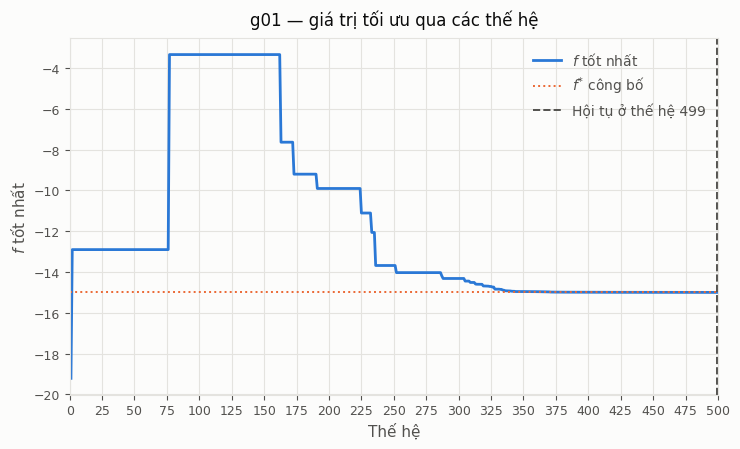

In [26]:
result_g01 = run_benchmark("g01")

## g06

$$
\begin{aligned}
&\underset{x_{1}, x_{2}}{\text{minimize}} \quad && f\left(x_{1}, x_{2}\right) = \left(x_{1} - 10\right)^{3} + \left(x_{2} - 20\right)^{3} \\
&\text{subject to} \quad && x_{1}^{2} - 10 x_{1} + x_{2}^{2} - 10 x_{2} - 50\ \ge\ 0 \\
& \quad && - x_{1}^{2} + 12 x_{1} - x_{2}^{2} + 10 x_{2} + 21.81\ \ge\ 0 \\
\end{aligned}
$$

Miền tìm kiếm: $13 \le x_{1} \le 100, \ 0 \le x_{2} \le 100$

| Thời gian (s) | Số thế hệ thỏa mãn | $f^{*}$ (GA) | $f^{*}$ (GA + tinh chỉnh) | $f^{*}$ (công bố) | Sai lệch | Vi phạm |
|---|---|---|---|---|---|---|
| $88.1194$ | $457$ | $-6898.4625238058$ | $-6961.8138755537$ | $-6961.8138755802$ | $2.6415 \times 10^{-8}$ | $0.0000000000$ |

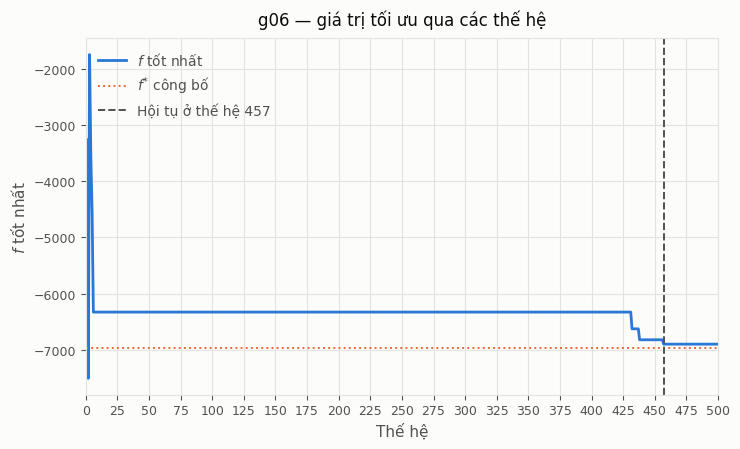

In [27]:
result_g06 = run_benchmark("g06")

## g08

$$
\begin{aligned}
&\underset{x_{1}, x_{2}}{\text{minimize}} \quad && f\left(x_{1}, x_{2}\right) = - \frac{\sin^{3}{\left(2 \pi x_{1} \right)} \sin{\left(2 \pi x_{2} \right)}}{x_{1}^{3} \left(x_{1} + x_{2}\right)} \\
&\text{subject to} \quad && - x_{1}^{2} + x_{2} - 1\ \ge\ 0 \\
& \quad && x_{1} - x_{2}^{2} + 8 x_{2} - 17\ \ge\ 0 \\
\end{aligned}
$$

Miền tìm kiếm: $0 \le x_{1} \le 10, \ 0 \le x_{2} \le 10$

| Thời gian (s) | Số thế hệ thỏa mãn | $f^{*}$ (GA) | $f^{*}$ (GA + tinh chỉnh) | $f^{*}$ (công bố) | Sai lệch | Vi phạm |
|---|---|---|---|---|---|---|
| $75.8673$ | $362$ | $-0.0958250414$ | $-0.0958250414$ | $-0.0958250414$ | $2.7756 \times 10^{-17}$ | $0.0000000000$ |

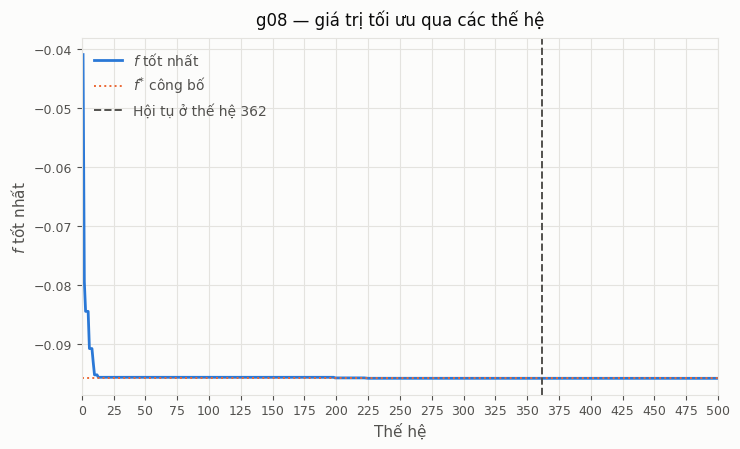

In [28]:
result_g08 = run_benchmark("g08")

## g11

$$
\begin{aligned}
&\underset{x_{1}, x_{2}}{\text{minimize}} \quad && f\left(x_{1}, x_{2}\right) = x_{1}^{2} + \left(x_{2} - 1\right)^{2} \\
&\text{subject to} \quad && - x_{1}^{2} + x_{2}\ =\ 0 \\
\end{aligned}
$$

Miền tìm kiếm: $-1 \le x_{1} \le 1, \ -1 \le x_{2} \le 1$

| Thời gian (s) | Số thế hệ thỏa mãn | $f^{*}$ (GA) | $f^{*}$ (GA + tinh chỉnh) | $f^{*}$ (công bố) | Sai lệch | Vi phạm |
|---|---|---|---|---|---|---|
| $67.0525$ | $392$ | $0.7502677229$ | $0.7502591856$ | $0.7499000000$ | $0.0003591856$ | $0.0000000000$ |

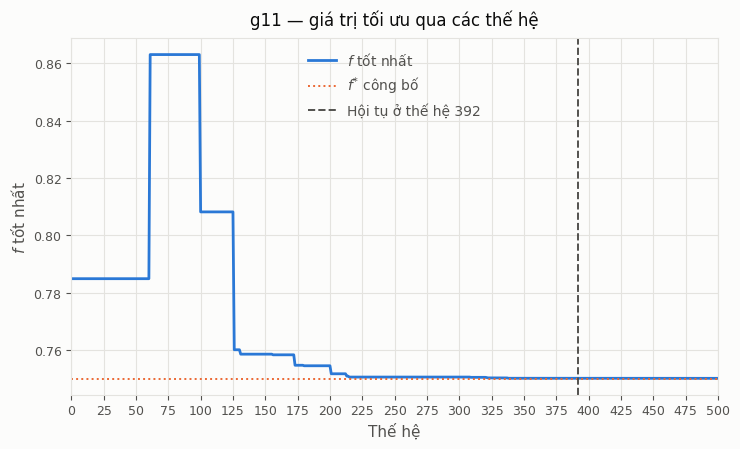

In [29]:
result_g11 = run_benchmark("g11")

## g15

$$
\begin{aligned}
&\underset{x_{1}, x_{2}, x_{3}}{\text{minimize}} \quad && f\left(x_{1}, x_{2}, x_{3}\right) = - x_{1}^{2} - x_{1} x_{2} - x_{1} x_{3} - 2 x_{2}^{2} - x_{3}^{2} + 1000 \\
&\text{subject to} \quad && x_{1}^{2} + x_{2}^{2} + x_{3}^{2} - 25\ =\ 0 \\
& \quad && 8 x_{1} + 14 x_{2} + 7 x_{3} - 56\ =\ 0 \\
\end{aligned}
$$

Miền tìm kiếm: $0 \le x_{1} \le 10, \ 0 \le x_{2} \le 10, \ 0 \le x_{3} \le 10$

| Thời gian (s) | Số thế hệ thỏa mãn | $f^{*}$ (GA) | $f^{*}$ (GA + tinh chỉnh) | $f^{*}$ (công bố) | Sai lệch | Vi phạm |
|---|---|---|---|---|---|---|
| $48.3078$ | $249$ | $961.7153739649$ | $961.7153083246$ | $961.7150222900$ | $0.0002860346$ | $0.0000000000$ |

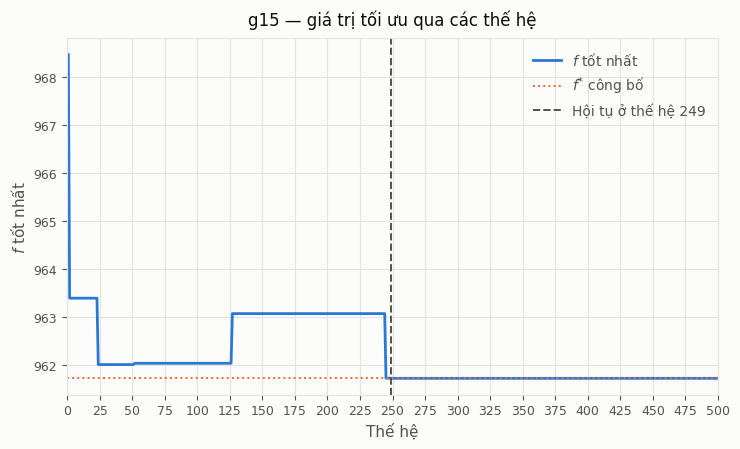

In [30]:
result_g15 = run_benchmark("g15")